In [118]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [102]:
DATASET = "/kaggle/input/datasets/confirm/google-landmark-dataset-v2-micro/gldv2_micro"

IMAGE_DIR = os.path.join(DATASET, "images")

train_df = pd.read_csv(os.path.join(DATASET,"train.csv"))

In [103]:
top20 = train_df["landmark_id"].value_counts().head(20).index

train_df = train_df[train_df["landmark_id"].isin(top20)].reset_index(drop=True)

print(train_df.shape)

(161, 2)


In [104]:
train_df["filepath"] = train_df["filename"].apply(
    lambda x: os.path.join(IMAGE_DIR,x)
)

In [105]:
encoder = LabelEncoder()

train_df["label"] = encoder.fit_transform(train_df["landmark_id"])

NUM_CLASSES = train_df["label"].nunique()

print(NUM_CLASSES)

20


In [106]:
train_paths,val_paths,train_labels,val_labels = train_test_split(

train_df["filepath"],
train_df["label"],
test_size=0.2,
random_state=42,
stratify=train_df["label"]

)

In [107]:
IMG_SIZE=224
BATCH_SIZE=32

def load_image(path,label):

    image=tf.io.read_file(path)

    image=tf.image.decode_jpeg(image,channels=3)

    image=tf.image.resize(image,(IMG_SIZE,IMG_SIZE))

    image=preprocess_input(image)

    return image,label

In [108]:
train_ds=tf.data.Dataset.from_tensor_slices((train_paths,train_labels))
val_ds=tf.data.Dataset.from_tensor_slices((val_paths,val_labels))

AUTOTUNE=tf.data.AUTOTUNE

train_ds=train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds=val_ds.map(load_image).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [119]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [121]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [122]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [123]:
early = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early]
)

Epoch 1/10


2026-07-18 09:45:50.053022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-18 09:45:50.192039: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0503 - loss: 3.8324

2026-07-18 09:46:07.139717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-18 09:46:07.274833: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.0312 - loss: 3.6793 - val_accuracy: 0.0909 - val_loss: 3.0527
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.0703 - loss: 3.2847 - val_accuracy: 0.0909 - val_loss: 2.9156
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.0781 - loss: 3.0355 - val_accuracy: 0.1515 - val_loss: 2.8417
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.1406 - loss: 2.9440 - val_accuracy: 0.1212 - val_loss: 2.8187
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.1172 - loss: 2.8009 - val_accuracy: 0.1515 - val_loss: 2.7513
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.1641 - loss: 2.6732 - val_accuracy: 0.1515 - val_loss: 2.6862
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2500 - loss: 2.5034 - val_accuracy: 0.2121 - val_loss: 2.6069
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.2656 - loss: 2.5265 - val_accuracy: 0.2424 - val_loss: 2.5771
Epoch

In [124]:
loss,acc=model.evaluate(val_ds)

print("Validation Accuracy :",acc*100)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3030 - loss: 2.4900
Validation Accuracy : 30.30303120613098


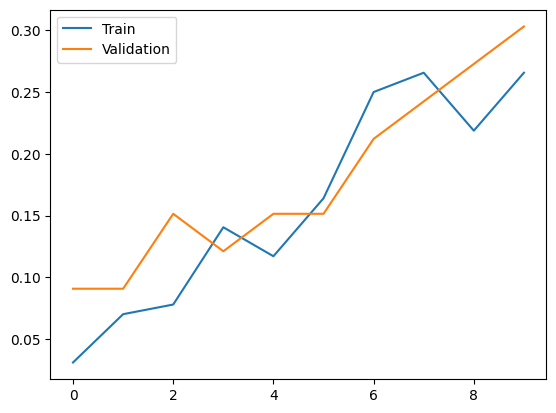

In [125]:
plt.plot(history.history["accuracy"],label="Train")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


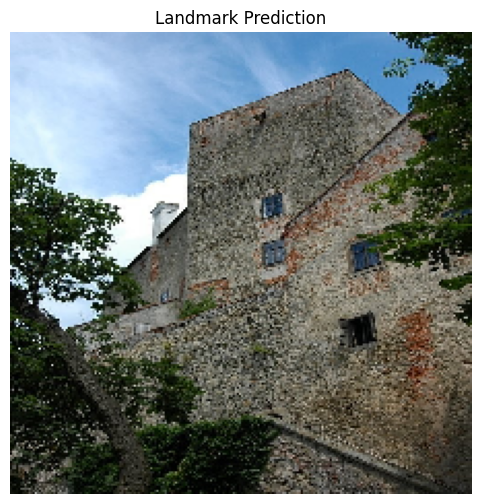

Actual Landmark ID    : 2062
Predicted Landmark ID : 2066
Confidence            : 11.47%


In [126]:
sample = train_df.sample(1).iloc[0]

img = tf.keras.preprocessing.image.load_img(
    sample["filepath"],
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

pred = np.argmax(prediction)

confidence = np.max(prediction) * 100

actual_id = sample["landmark_id"]
predicted_id = encoder.inverse_transform([pred])[0]

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title("Landmark Prediction")
plt.show()

print("="*40)
print("Actual Landmark ID    :", actual_id)
print("Predicted Landmark ID :", predicted_id)
print("Confidence            : {:.2f}%".format(confidence))
print("="*40)

In [127]:
model.save("LandmarkRecognition_MobileNetV2.keras")